In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import BaseEstimator, RegressorMixin

1. Data preparation & exploratory analysis

In [25]:
# Load the data
df = pd.read_csv('../data/raw/crime.csv')

In [26]:
# Display the first five rows, all columns data types, and the dataset shape
print(df.head(5))
print(df.dtypes)
print(df.shape)

        state  murder.rate  poverty  high.school  college  single.parent  \
0     Alabama          7.4     14.7         77.5     20.4           26.0   
1      Alaska          4.3      8.4         90.4     28.1           23.2   
2     Arizona          7.0     13.5         85.1     24.6           23.5   
3    Arkansas          6.3     15.8         81.7     18.4           24.7   
4  California          6.1     14.0         81.2     27.5           21.8   

   unemployed  metropolitan region  
0         4.6          70.2  South  
1         6.6          41.6   West  
2         3.9          87.9   West  
3         4.4          49.0  South  
4         4.9          96.7   West  
state                str
murder.rate      float64
poverty          float64
high.school      float64
college          float64
single.parent    float64
unemployed       float64
metropolitan     float64
region               str
dtype: object
(50, 9)


In [27]:
# Report descriptive statistics (mean, std, min, max, quartiles) for all numeric variables
print(df.describe())

       murder.rate    poverty  high.school    college  single.parent  \
count    50.000000  50.000000    50.000000  50.000000      50.000000   
mean      4.604000  11.440000    85.482000  24.932000      22.970000   
std       2.510221   2.937096     3.959782   4.312319       3.038814   
min       0.600000   7.300000    77.100000  15.300000      13.600000   
25%       2.600000   9.425000    82.525000  22.525000      20.950000   
50%       4.550000  10.550000    86.100000  24.450000      22.800000   
75%       6.300000  13.375000    88.175000  27.450000      24.575000   
max      12.500000  19.300000    91.800000  34.600000      30.000000   

       unemployed  metropolitan  
count   50.000000     50.000000  
mean     3.904000     67.726000  
std      0.947383     20.562099  
min      2.200000     27.900000  
25%      3.225000     49.800000  
50%      3.900000     70.250000  
75%      4.400000     84.375000  
max      6.600000    100.000000  


In [29]:
# Check for missing values. Report the count and percentage of missing entries per columns 
# and state how missing values will be handled during modeling
print(f"The number of missing values: \n{df.isnull().sum()}")
print(f"\nThe percentage of missing values: \n{df.isnull().mean().astype(str) + ' %'}")
print("\nSince there are no missing values in this dataset, we do not need to handle them."
      "\nHowever, imputing values or dropping rows that contain missing values is usually done when they exist.")

The number of missing values: 
state            0
murder.rate      0
poverty          0
high.school      0
college          0
single.parent    0
unemployed       0
metropolitan     0
region           0
dtype: int64

The percentage of missing values: 
state            0.0 %
murder.rate      0.0 %
poverty          0.0 %
high.school      0.0 %
college          0.0 %
single.parent    0.0 %
unemployed       0.0 %
metropolitan     0.0 %
region           0.0 %
dtype: str

Since there are no missing values in this dataset, we do not need to handle them.
However, imputing values or dropping rows that contain missing values is usually done when they exist.


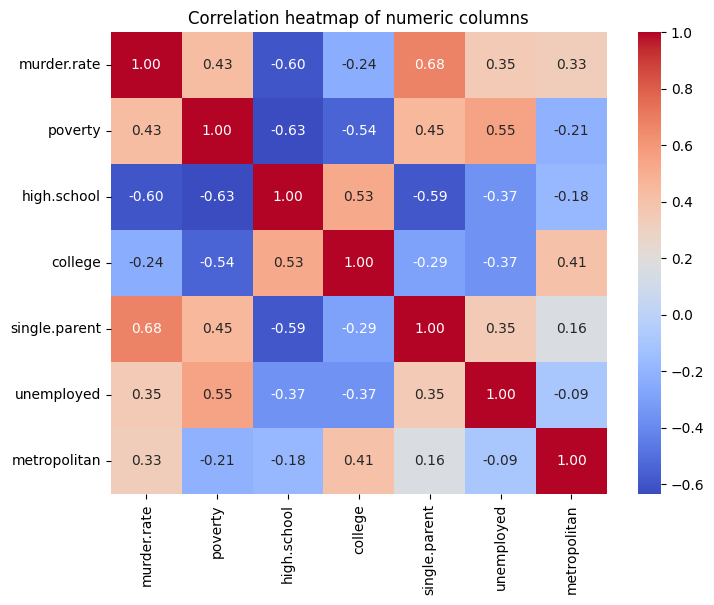

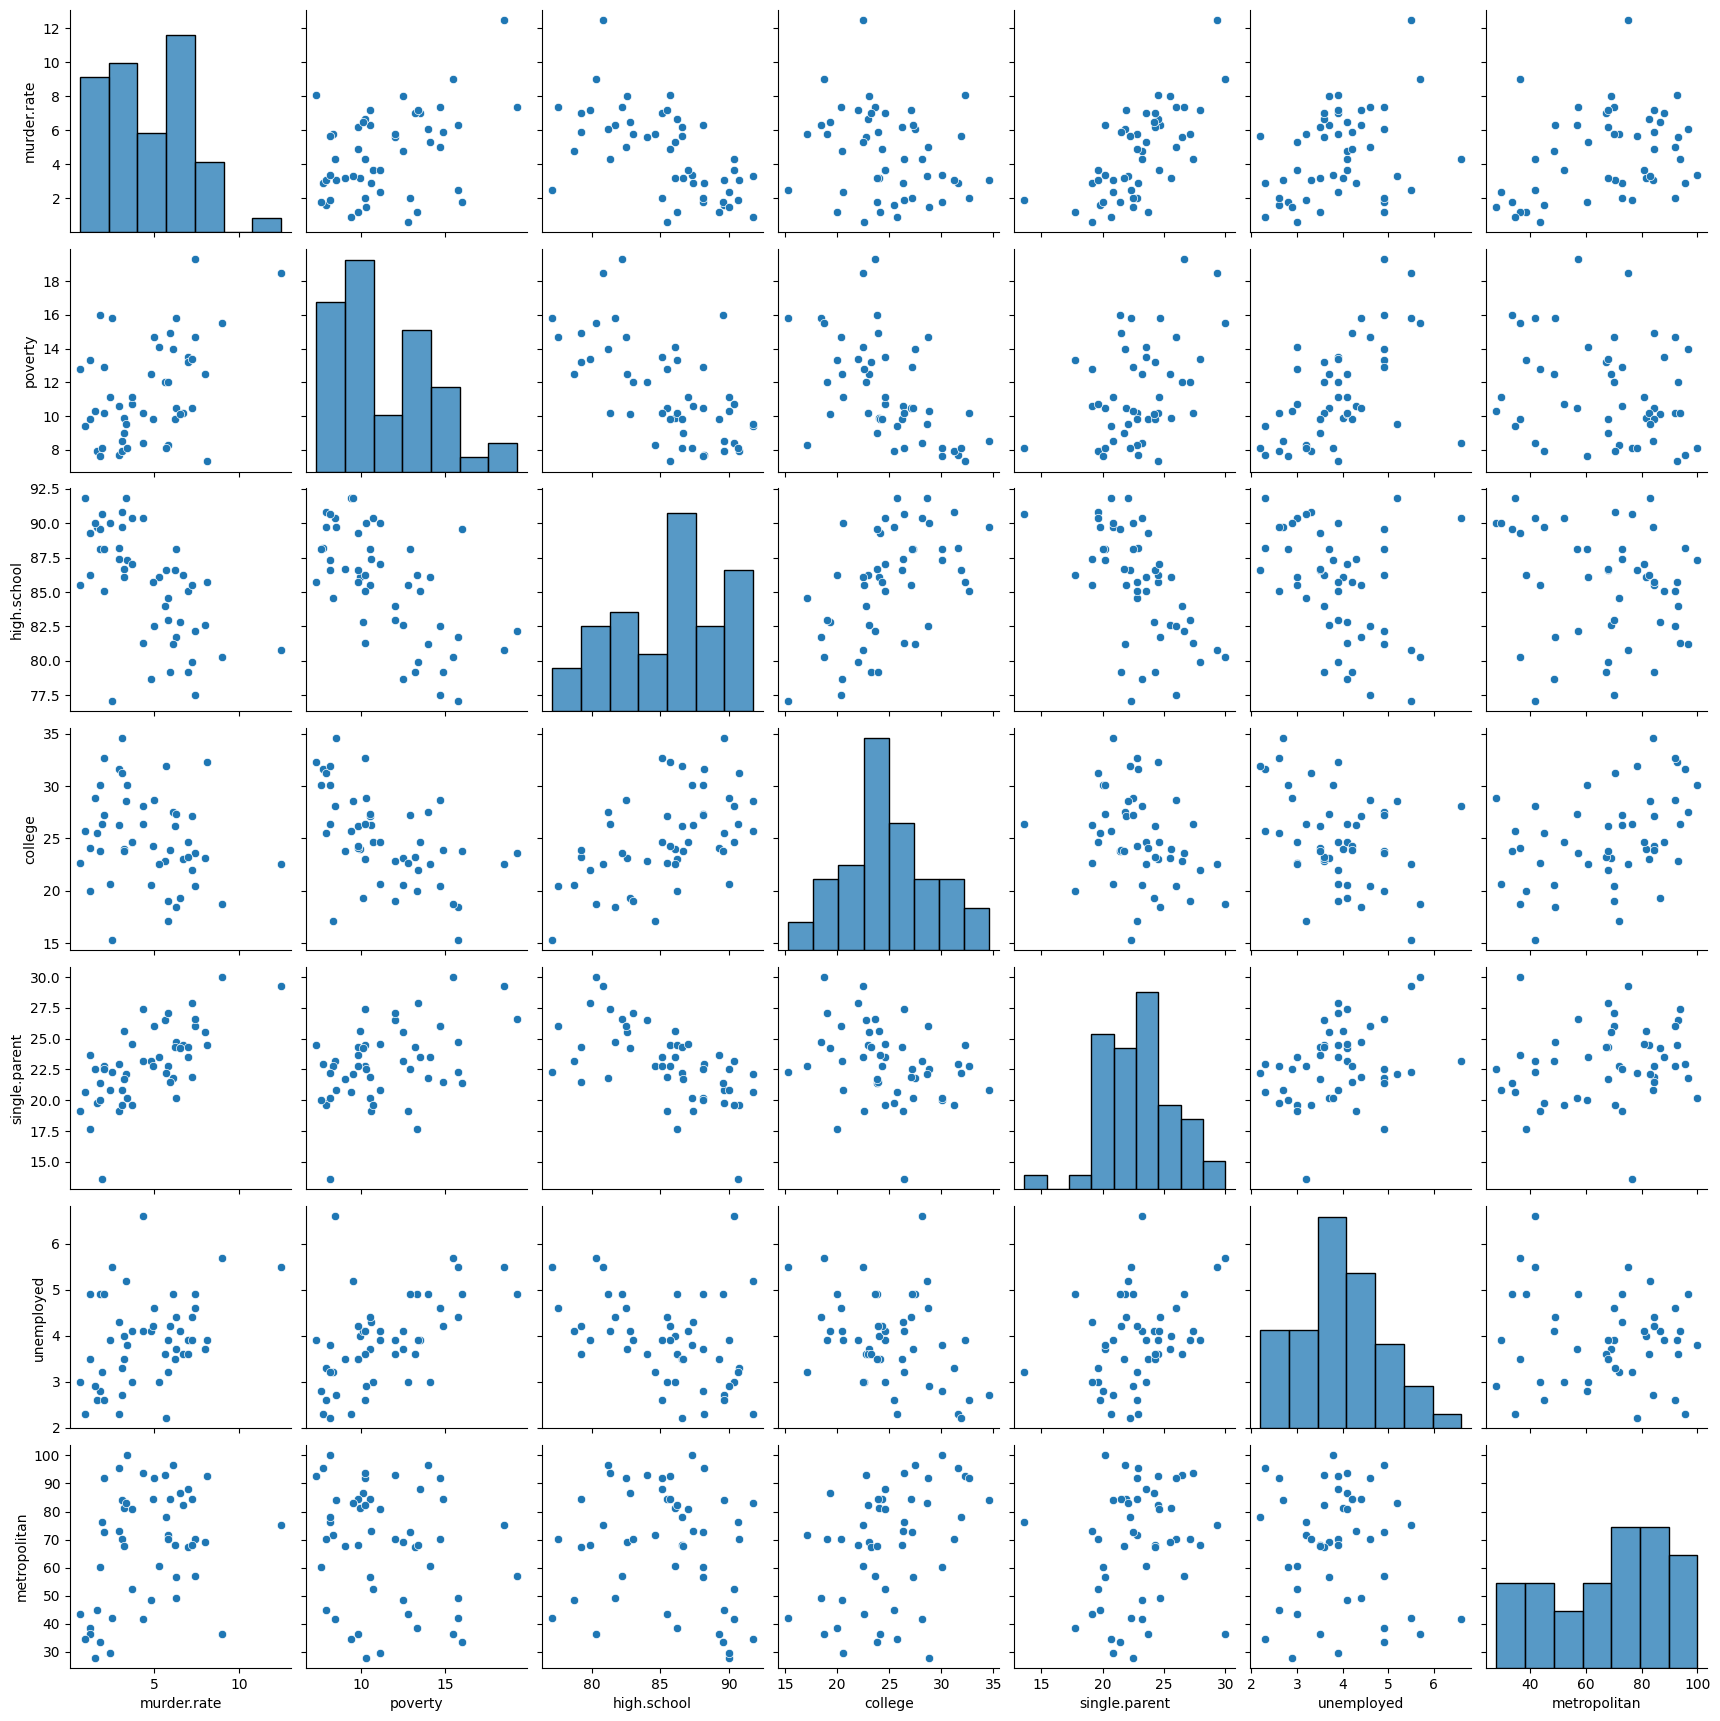

Seems like there is a strong positive relationship between murder rate and single parent. If the parent don't have atime to take care of their children.
On the other hand, high school is negatively correlated with murder rate. This might be because people who didn'tgo to high school are likly to be people who is not socially unstable


In [45]:
# Produce a correlation heat map and a pair plot for the numeric predictors and target (murder).
# Comment on at least two notable relationships visible in the plots.

# Identify numericl columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Build correlation matrix and heatmap
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap of numeric columns")
plt.show()

# Pairwise scatterplot grid
sns.pairplot(df, vars=numeric_cols)
plt.show()

# Comment
print("Seems like there is a strong positive relationship between murder rate and single parent. If the parent don't have a" \
"time to take care of their children.\n" \
"On the other hand, high school is negatively correlated with murder rate. This might be because people who didn't" \
"go to high school are likly to be people who is not socially unstable")

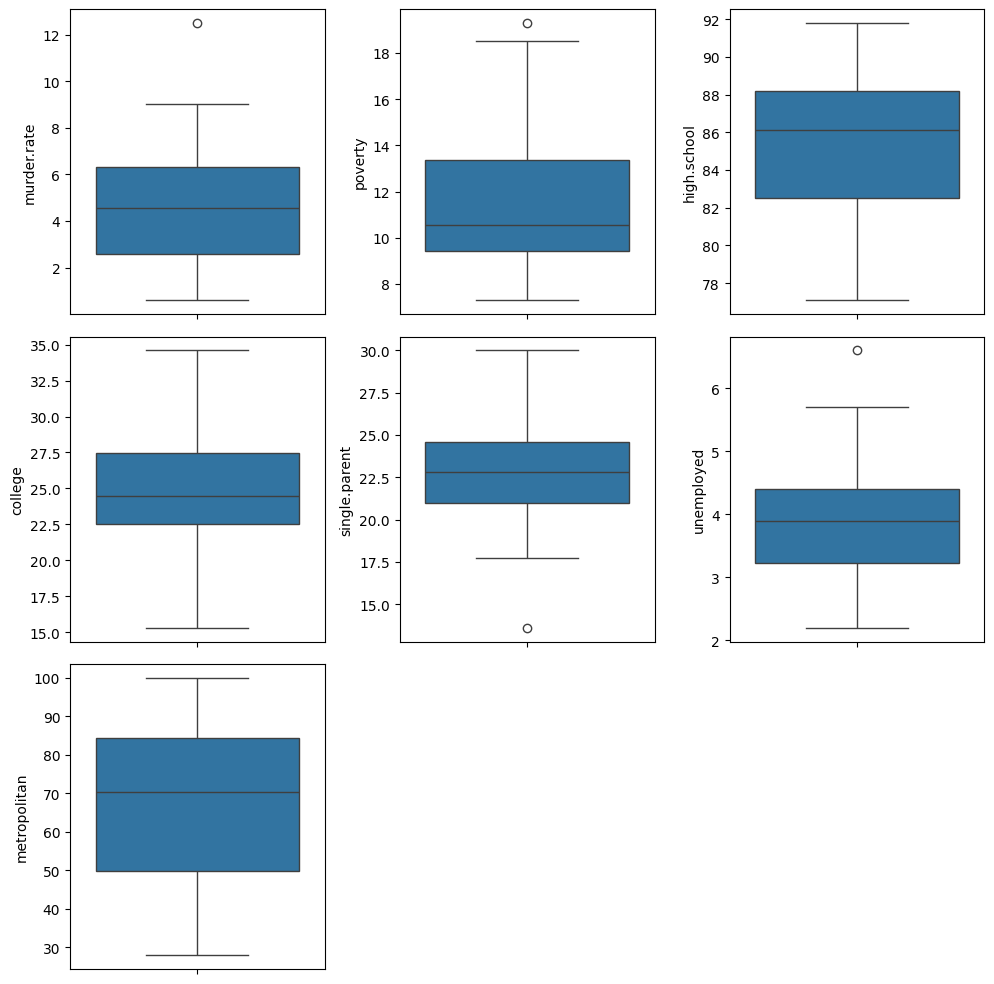

Altough outlier exist in some column, they likely represent real high-crime regions rather than daata errors 
and this dataset has only 50 rows, each datapoint has much information compared to other dataset that has huge data points.
So they were retained.


In [59]:
# Identify obvious outliers using box plots. State clearly how outliers will be handled (e.g.,
# retained, capped, or removed) and justify your decision.
n_plots = len(numeric_cols)
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols,
                         figsize=(10, 10), sharex=False)
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_ylabel(col)

# hide any unused subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Comment
print("Altough outlier exist in some column, they likely represent real high-crime regions rather than daata errors \n" \
"and this dataset has only 50 rows, each datapoint has much information compared to other dataset that has huge data points.\n" \
"So they were retained.")

2. Scikit-learn baseline pipeline

In [ ]:
# Build a Pipeline that integrates a ColumnTransformer with the following steps in order
    # Missing value imputation (median strategy for numeric features)
    # One-hot-encoding for 'region' (with drop='first' to avoid multicollinearity)
    # Standardization of all numeric features using StandardScaler
    # scikit-learns' LinearRegression estimator
numerical_features = ['poverty', 'high.school', 'college', 'single.parent', 'unemployed', 'metropolitan']
categorical_features = ['region']

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('OneHot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lr', LinearRegression())
])

In [66]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [80]:
X = df.drop('murder.rate', axis=1).copy()
y = df['murder.rate']

In [81]:
# Split the data 50/50 (train/test) using random state=42 for reproducibility. 
# Fit the pipeline on the training split and evaluate it on the test split. Report R2 and RMSE for both splits.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [82]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [88]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"R2 train: {r2_train:.4f}")
print(f"R2 test: {r2_test:.4f}")

print(f"RMSE train: {rmse_train:.4f}")
print(f"RMSE test: {rmse_test:.4f}")

R2 train: 0.7496
R2 test: 0.3021
RMSE train: 1.1517
RMSE test: 1.8506


In [102]:
# Evaluate the pipeline using 3-fold cross-validation. 
# Report the mean and standard deviation of R2 and RMSE across folds.
r2_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=3,
    scoring='r2'
)

rmse_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=3,
    scoring='neg_root_mean_squared_error'
)

rmse_scores = -rmse_scores

r2_mean = r2_scores.mean()
r2_std = r2_scores.std()

rmse_mean = rmse_scores.mean()
rmse_std = rmse_scores.std()

print(f"R2 mean: {r2_mean:.4f}")
print(f"R2 std: {r2_std:.4f}")
print(f"RMSE mean: {rmse_mean:.4f}")
print(f"RMSE std: {rmse_std:.4f}")

R2 mean: -0.7235
R2 std: 0.5672
RMSE mean: 2.6562
RMSE std: 0.2427


In [ ]:
# Compare the CV performance to the simple train/test result from (b). 
# Discuss briefly: which estimate is more reliable and why?
print("The normal splitting give positive R2 scores which might be overfitting, whereas" \
"cross validation give negative R2 scores. That means model performs since the dataset is small." \
"Regard to RMSE, splitting model performs better than cross validation model based on score")

3. Mini-batch gradient descent from scratch

In [109]:
class LinearRegressionGD(BaseEstimator, RegressorMixin):
    def __init__(self, eta=0.01, n_iter=50, batch_size=8, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.batch_size = batch_size # Add a batch_size with default 8
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []
        self.n_features_in_ = X.shape[1]

        for i in range(self.n_iter):
            # Use rgen.permutation to shuffle the training indices at the start of every epoch
            indices = rgen.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0.0
            n_batches = 0

            for start in range(0, X.shape[0], self.batch_size):
                # slice shuffled into mini batches without replacement
                # Retain the partial final batch if N is not divisible by batch_size
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                # Apply the gradient update formulas
                output = self.net_input(X_batch)
                errors = (y_batch - output)
                self.w_ += self.eta * 2.0 * X_batch.T.dot(errors) / X_batch.shape[0]
                self.b_ += self.eta * 2.0 * errors.mean()
                batch_loss = (errors ** 2).mean()
                epoch_loss += batch_loss
                n_batches += 1

            # Append the MSE
            self.losses_.append(epoch_loss / n_batches)
        return self
    
    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return self.net_input(X)

In [110]:
# Train the full-batch LinearRegressionGD (Listing 1) with n iter=500 and eta=0.01.
# Report training and test R2 and RMSE
full_batch = LinearRegressionGD(eta=0.01, n_iter=500, batch_size=1)

In [111]:
full_batch.fit(X_train, y_train)

KeyError: "None of [Index([12,  8,  2, 20,  3,  5, 16, 24, 23, 21,  1, 22,  6,  7, 15, 19, 13,  0,\n       17,  9,  4, 18, 14, 10, 11],\n      dtype='int32')] are in the [columns]"